   YEAR  MONTH                           SUPPLIER ITEM CODE  \
0  2020      1  REPUBLIC NATIONAL DISTRIBUTING CO    100009   
1  2020      1                          PWSWN INC    100024   
2  2020      1            RELIABLE CHURCHILL LLLP      1001   
3  2020      1          LANTERNA DISTRIBUTORS INC    100145   
4  2020      1               DIONYSOS IMPORTS INC    100293   

                      ITEM DESCRIPTION ITEM TYPE  RETAIL SALES  \
0                  BOOTLEG RED - 750ML      WINE          0.00   
1            MOMENT DE PLAISIR - 750ML      WINE          0.00   
2  S SMITH ORGANIC PEAR CIDER - 18.7OZ      BEER          0.00   
3        SCHLINK HAUS KABINETT - 750ML      WINE          0.00   
4       SANTORINI GAVALA WHITE - 750ML      WINE          0.82   

   RETAIL TRANSFERS  WAREHOUSE SALES  
0               0.0              2.0  
1               1.0              4.0  
2               0.0              1.0  
3               0.0              1.0  
4               0.0          

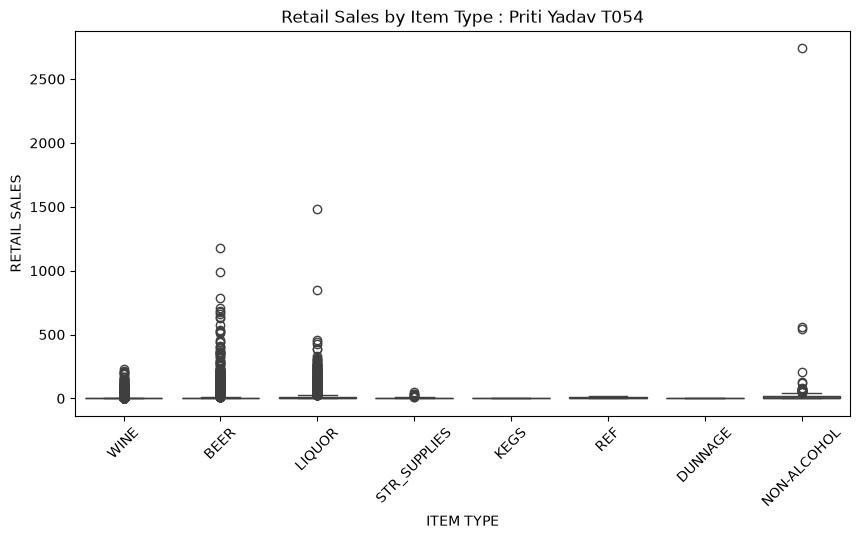


H0: Average retail sales are equal among all item types.
H1: Average retail sales are different among item types.

F-statistic: nan
p-value: nan
Do not reject H0
There is no significant difference in retail sales among item types.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

# 1. Load dataset
df = pd.read_csv("Retail and wherehouse Sale.csv")

# 2. Display first five records and shape
print(df.head())
print("Rows and Columns:", df.shape)

# 3. Display column names and data types
print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

# 4. Check missing values and duplicates
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

# 5. Display ITEM TYPE categories
print("\nITEM TYPE:")
print(df["ITEM TYPE"].unique())

# 6. Average RETAIL SALES for each ITEM TYPE
average_sales = df.groupby("ITEM TYPE")["RETAIL SALES"].mean()

print("\nAverage Retail Sales:")
print(average_sales)

# 7. Box plot
plt.figure(figsize=(10,5))
sns.boxplot(x="ITEM TYPE", y="RETAIL SALES", data=df)
plt.title("Retail Sales by Item Type : Priti Yadav T054")
plt.xticks(rotation=45)
plt.show()

# 8. Hypotheses
print("\nH0: Average retail sales are equal among all item types.")
print("H1: Average retail sales are different among item types.")

# 9. One-way ANOVA
groups = []

for item in df["ITEM TYPE"].unique():
    groups.append(
        df[df["ITEM TYPE"] == item]["RETAIL SALES"]
    )

f, p = f_oneway(*groups)

# 10. F-statistic and p-value
print("\nF-statistic:", f)
print("p-value:", p)

# 11 & 12. Decision
if p < 0.05:
    print("Reject H0")
else:
    print("Do not reject H0")

# 13. Conclusion
if p < 0.05:
    print("There is a significant difference in retail sales among item types.")
else:
    print("There is no significant difference in retail sales among item types.")

Selected Data:
  ITEM TYPE  YEAR  RETAIL SALES
0      WINE  2020          0.00
1      WINE  2020          0.00
2      BEER  2020          0.00
3      WINE  2020          0.00
4      WINE  2020          0.82

Years available:
[2020]

Average Retail Sales:
ITEM TYPE     YEAR
BEER          2020    14.118748
DUNNAGE       2020     0.000000
KEGS          2020     0.000000
LIQUOR        2020    13.635171
NON-ALCOHOL   2020    31.742419
REF           2020     5.783750
STR_SUPPLIES  2020     5.485714
WINE          2020     3.195334
Name: RETAIL SALES, dtype: float64


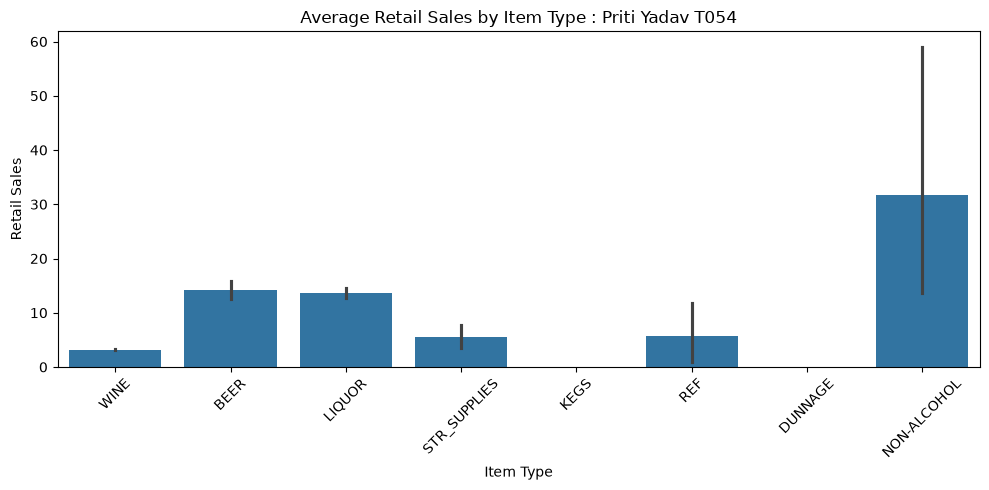


Factorial ANOVA cannot be performed.
Reason: The dataset contains only one YEAR (2020).
Therefore, the effect of YEAR and ITEM TYPE × YEAR
interaction cannot be calculated.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Load dataset
df = pd.read_csv("Retail and wherehouse Sale.csv")

# Remove missing values
df = df.dropna(subset=["ITEM TYPE", "YEAR", "RETAIL SALES"])

# 14. Select ITEM TYPE, YEAR and RETAIL SALES
data = df[["ITEM TYPE", "YEAR", "RETAIL SALES"]]

print("Selected Data:")
print(data.head())

# Check number of years
print("\nYears available:")
print(data["YEAR"].unique())

# 15. Average retail sales for each ITEM TYPE and YEAR
average_sales = data.groupby(
    ["ITEM TYPE", "YEAR"]
)["RETAIL SALES"].mean()

print("\nAverage Retail Sales:")
print(average_sales)

# 16. Visualization
plt.figure(figsize=(10, 5))

sns.barplot(
    data=data,
    x="ITEM TYPE",
    y="RETAIL SALES"
)

plt.title("Average Retail Sales by Item Type : Priti Yadav T054")
plt.xlabel("Item Type")
plt.ylabel("Retail Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Check whether YEAR has more than one value
if data["YEAR"].nunique() < 2:

    print("\nFactorial ANOVA cannot be performed.")
    print("Reason: The dataset contains only one YEAR (2020).")
    print("Therefore, the effect of YEAR and ITEM TYPE × YEAR")
    print("interaction cannot be calculated.")

else:

    # 17, 18, 19 and 20. Factorial ANOVA
    model = ols(
        "Q('RETAIL SALES') ~ C(Q('ITEM TYPE')) * C(YEAR)",
        data=data
    ).fit()

    anova = sm.stats.anova_lm(model, typ=2)

    # 21. Display results
    print("\nFactorial ANOVA Results:")
    print(anova)

    # 22. Check significance
    print("\nSignificance:")

    for effect in anova.index:

        if effect != "Residual":

            p = anova.loc[effect, "PR(>F)"]

            if p < 0.05:
                print(effect, "is Significant")
            else:
                print(effect, "is Not Significant")

    # 23. Conclusion
    print("\nConclusion:")
    print("Factorial ANOVA was performed successfully.")